# 🧠 Phase 3 — CNN Baseline Model
**Backbone:** ResNet-50 (ImageNet pretrained)
**Strategy:** Extract 20 frames → CNN features → mean pool → classify

This notebook trains the CNN baseline and establishes performance benchmarks.

In [2]:
import sys, os
sys.path.insert(0, "../src")
import torch, torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import set_seed, get_device, CLASS_NAMES, plot_training_curves
from dataset import get_dataloader
from model import CNNBaseline

set_seed(42)
device = get_device()


c:\Users\Abhinav\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU | VRAM: 6.4 GB


In [3]:
# ── Hyperparameters ──────────────────────────────────────
BATCH_SIZE = 8   # Reduce to 4 if OOM
EPOCHS = 20
LR = 1e-4
NUM_FRAMES = 20
DATA_ROOT = "../data/raw"

# ── DataLoaders ──────────────────────────────────────────
print("Loading data...")
train_loader, train_ds = get_dataloader(DATA_ROOT, "train", BATCH_SIZE, num_workers=4, num_frames=NUM_FRAMES)
val_loader,   val_ds   = get_dataloader(DATA_ROOT, "val",   BATCH_SIZE, num_workers=4, num_frames=NUM_FRAMES)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")


Loading data...
  ✅ Loaded 21 class names from lable.txt
  [train] 939 videos | 21 classes | from train/
  ✅ Loaded 21 class names from lable.txt
  [val] 194 videos | 21 classes | from val/
Train: 939 | Val: 194


In [4]:
# ── Model Setup ──────────────────────────────────────────
model = CNNBaseline(num_classes=21, dropout=0.5, pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: CNN Baseline (ResNet50)")
print(f"Trainable params: {total_params:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=7, gamma=0.3)
scaler = GradScaler()


Model: CNN Baseline (ResNet50)
Trainable params: 24,567,893


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_34972\592487329.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [5]:
# ── Training Loop ────────────────────────────────────────
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for frames, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch:02d} [Train]", leave=False):
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            out = model(frames)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        t_loss += loss.item() * labels.size(0)
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total += labels.size(0)
    scheduler.step()

    # Validate
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for frames, labels, _ in tqdm(val_loader, desc=f"Epoch {epoch:02d} [Val]  ", leave=False):
            frames, labels = frames.to(device), labels.to(device)
            with autocast():
                out = model(frames)
                loss = criterion(out, labels)
            v_loss += loss.item() * labels.size(0)
            v_correct += (out.argmax(1) == labels).sum().item()
            v_total += labels.size(0)

    tl, ta = t_loss/t_total, 100*t_correct/t_total
    vl, va = v_loss/v_total, 100*v_correct/v_total
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)

    print(f"Epoch {epoch:02d} | TLoss={tl:.4f} TAcc={ta:.1f}% | VLoss={vl:.4f} VAcc={va:.1f}%")

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), "../models/saved/cnn_baseline_best.pth")
        print(f"  💾 Best model saved! (Val Acc: {best_val_acc:.2f}%)")

print(f"\n✅ Training done! Best Val Acc: {best_val_acc:.2f}%")


Epoch 01 [Train]:   0%|          | 0/118 [00:00<?, ?it/s]C:\Users\Abhinav\AppData\Local\Temp\ipykernel_34972\2733501180.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 01 [Val]  :   0%|          | 0/25 [00:00<?, ?it/s]           C:\Users\Abhinav\AppData\Local\Temp\ipykernel_34972\2733501180.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | TLoss=2.6245 TAcc=24.1% | VLoss=2.2944 VAcc=42.3%
  💾 Best model saved! (Val Acc: 42.27%)


Epoch 02 | TLoss=2.1154 TAcc=40.8% | VLoss=2.1939 VAcc=42.8%
  💾 Best model saved! (Val Acc: 42.78%)


Epoch 03 | TLoss=1.8633 TAcc=51.7% | VLoss=2.2025 VAcc=47.4%
  💾 Best model saved! (Val Acc: 47.42%)


Epoch 04 | TLoss=1.7226 TAcc=59.0% | VLoss=2.6600 VAcc=41.8%


...

Epoch 16 | TLoss=0.7296 TAcc=99.3% | VLoss=2.5181 VAcc=44.3%


Epoch 17 | TLoss=0.7195 TAcc=99.5% | VLoss=2.5662 VAcc=43.3%


Epoch 18 | TLoss=0.7190 TAcc=99.6% | VLoss=2.4739 VAcc=43.8%


Epoch 19 | TLoss=0.7219 TAcc=98.9% | VLoss=2.5138 VAcc=42.3%


Epoch 20 | TLoss=0.7045 TAcc=99.8% | VLoss=2.4788 VAcc=44.3%

✅ Training done! Best Val Acc: 47.42%


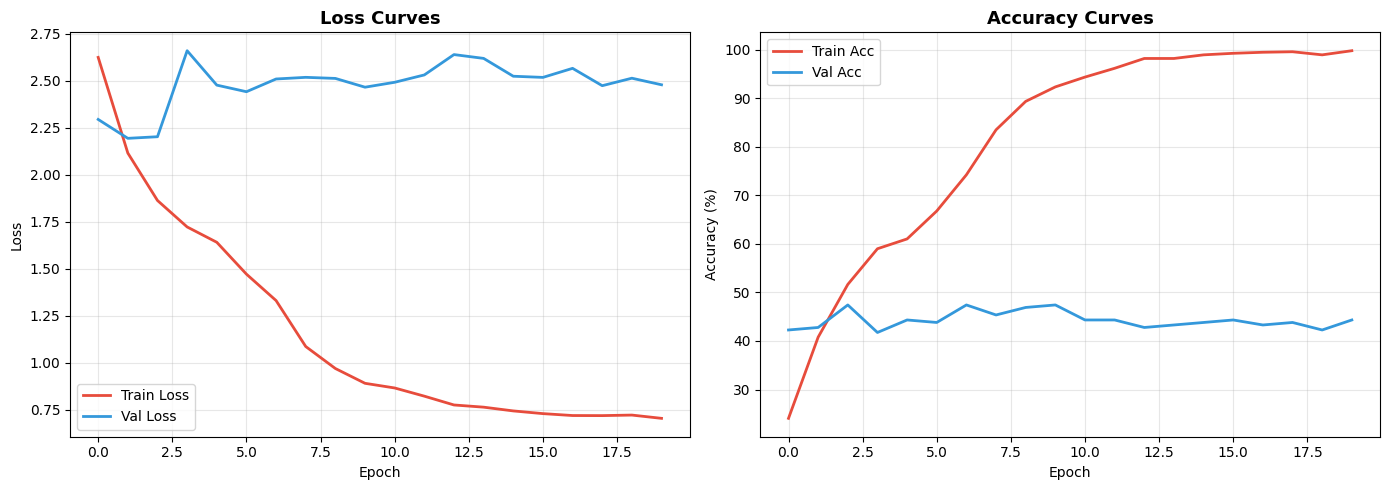

In [6]:
# ── Plot Training Curves ─────────────────────────────────
import os
os.makedirs("../results/plots", exist_ok=True)
plot_training_curves(train_losses, val_losses, train_accs, val_accs,
                     save_path="../results/plots/cnn_baseline_curves.png")
plt.show()
